# Telco Customer Churn Analysis
**Цель:** выявить ключевые факторы оттока и предложить меры по удержанию клиентов.
**Данные:** 7 043 клиента телеком-компании, 26.5% оттока.
**Инструменты:** SQL (PostgreSQL), Python (pandas, matplotlib, seaborn, scikit-learn).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\egor-\PycharmProjects\Churn project\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
print(df.info())
print(df.head())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

## Ключевые выводы
- **Самый опасный сегмент:** помесячный контракт + Fiber optic → отток 54.6%.
- **Удерживающие факторы:** наличие OnlineSecurity и TechSupport снижает отток в 2 раза.
- **Финансовый убыток:** «дорогие» клиенты (высокий ежемесячный платёж) уходят вдвое быстрее.
- **Способ оплаты:** Electronic check – максимальный отток (45.3%), автоплатежи – минимальный.

## Предсказательная модель (Logistic Regression)
| Метрика | Значение |
|---------|----------|
| Accuracy | 0.78 |
| Precision (class 1) | 0.59 |
| Recall (class 1) | 0.53 |
| F1-score (class 1) | 0.56 |
| ROC-AUC | 0.83 |

Модель хорошо разделяет классы (AUC 0.83), но требует улучшения recall для оттока (сейчас 0.53).
Признаки с наибольшим влиянием: `Contract`, `InternetService`, `PaymentMethod`, `Tenure`.

In [8]:
# Преобразуем TotalCharges в число
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Удаляем строки с пропусками (их мало)
df = df.dropna()
# Преобразуем Churn в 0/1
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,32.421786,64.798208,2283.300441


## Рекомендации
1. **Безопасный старт** – бесплатный OnlineSecurity на 3 месяца для новых помесячных клиентов Fiber optic.
2. **Переход на годовой контракт** – скидка 10% на 3-й месяц.
3. **Пакет лояльности** – месяц бесплатно при подключении безопасности текущим клиентам.
4. **Стимулирование автоплатежа** – скидка $2/мес. за отказ от Electronic check.

In [12]:
df_raw = pd.read_csv(r"C:\Users\egor-\PycharmProjects\Churn project\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df_raw['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [23]:
import pandas as pd

# Загрузка
df = pd.read_csv(r"C:\Users\egor-\PycharmProjects\Churn project\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Проверка исходных значений Churn
print("Исходные значения Churn:")
print(df['Churn'].value_counts())

# Преобразование Churn в 0/1
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Проверка после преобразования
print("\nПосле преобразования:")
print(df['Churn'].value_counts())

# Приведение TotalCharges к числу
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().copy()

# Теперь считаем отток по контрактам
print("\nОтток по типу контракта (%):")
churn_by_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(churn_by_contract)

Исходные значения Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

После преобразования:
Churn
0    5174
1    1869
Name: count, dtype: int64

Отток по типу контракта (%):
Churn                   0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


In [24]:
# Создаём группы по tenure (например, 0-6 мес, 6-12 мес, 12-24 мес, >24 мес)
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,6,12,24,100], labels=['<6', '6-12', '12-24', '>24'])

# Для каждого типа контракта смотрим отток по tenure_group
for contract in df['Contract'].unique():
    subset = df[df['Contract'] == contract]
    churn_by_tenure = pd.crosstab(subset['tenure_group'], subset['Churn'], normalize='index') * 100
    print(f"\nКонтракт: {contract}")
    print(churn_by_tenure)


Контракт: Month-to-month
Churn                 0          1
tenure_group                      
<6            44.798301  55.201699
6-12          58.003442  41.996558
12-24         62.279512  37.720488
>24           69.143357  30.856643

Контракт: One year
Churn                 0          1
tenure_group                      
<6            89.473684  10.526316
6-12          89.411765  10.588235
12-24         91.878173   8.121827
>24           88.107639  11.892361

Контракт: Two year
Churn                  0         1
tenure_group                      
<6            100.000000  0.000000
6-12          100.000000  0.000000
12-24         100.000000  0.000000
>24            96.877033  3.122967


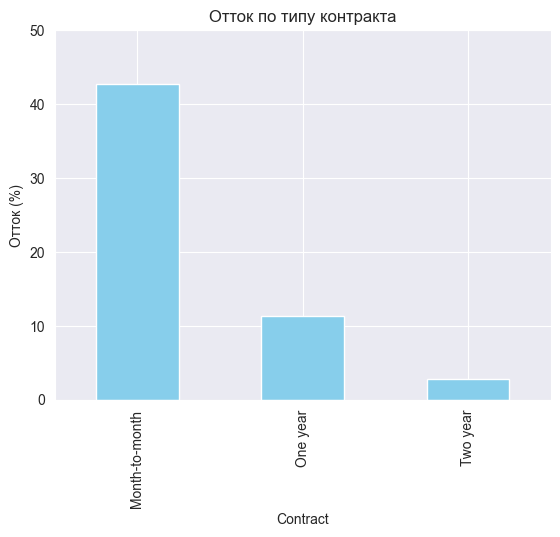

C:\Users\egor-\AppData\Local\Temp\ipykernel_20244\3268824859.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = monthly.groupby('tenure_group')['Churn'].mean() * 100


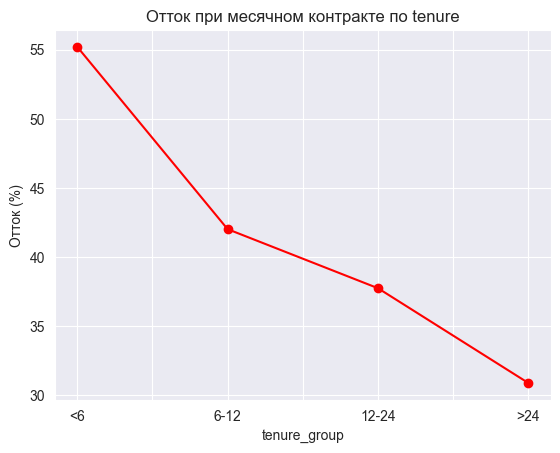

In [21]:
import matplotlib.pyplot as plt

# График 1: отток по контрактам
churn_by_contract = df.groupby('Contract')['Churn'].mean() * 100
churn_by_contract.plot(kind='bar', color='skyblue')
plt.ylabel('Отток (%)')
plt.title('Отток по типу контракта')
plt.ylim(0, 50)
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

# График 2: для месячного контракта по tenure
monthly = df[df['Contract'] == 'Month-to-month']
tenure_churn = monthly.groupby('tenure_group')['Churn'].mean() * 100
tenure_churn.plot(kind='line', marker='o', color='red')
plt.ylabel('Отток (%)')
plt.title('Отток при месячном контракте по tenure')
plt.savefig('churn_by_tenure_monthly.png', dpi=150)
plt.show()

Загружено строк: 7032
Распределение Churn:
Churn
0    5163
1    1869
Name: count, dtype: int64

=== Отток по типу контракта (%%) ===
Churn                   0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


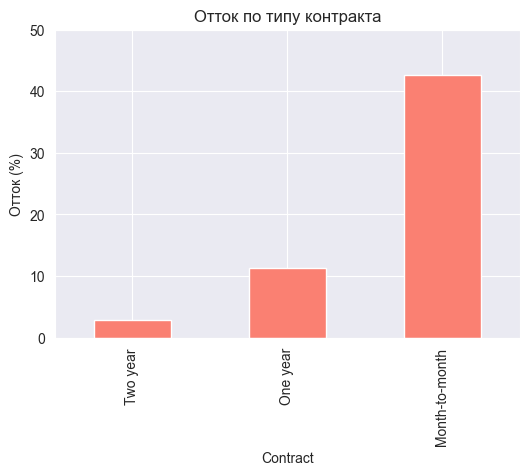


=== Отток по MonthlyCharges для контракта Month-to-month ===
charge_group
Q1 (низкие)     29.290853
Q2              35.714286
Q3              53.877973
Q4 (высокие)    52.012384
Name: Churn, dtype: float64


C:\Users\egor-\AppData\Local\Temp\ipykernel_12088\2546244871.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_charge = subset.groupby('charge_group')['Churn'].mean() * 100


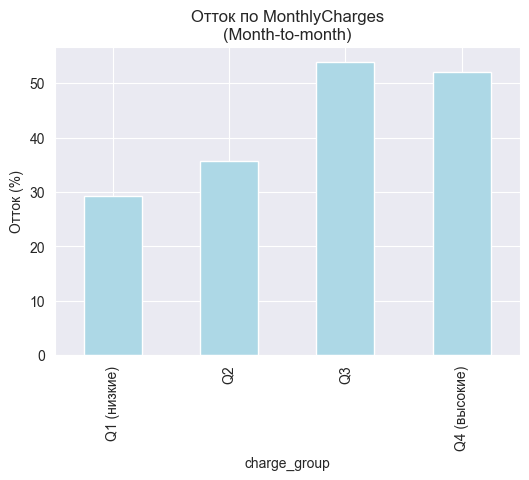

C:\Users\egor-\AppData\Local\Temp\ipykernel_12088\2546244871.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_charge = subset.groupby('charge_group')['Churn'].mean() * 100
C:\Users\egor-\AppData\Local\Temp\ipykernel_12088\2546244871.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_charge = subset.groupby('charge_group')['Churn'].mean() * 100
C:\Users\egor-\AppData\Local\Temp\ipykernel_12088\2546244871.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=T


=== Отток по MonthlyCharges для контракта One year ===
charge_group
Q1 (низкие)      2.717391
Q2               7.859079
Q3              11.716621
Q4 (высокие)    22.826087
Name: Churn, dtype: float64

=== Отток по MonthlyCharges для контракта Two year ===
charge_group
Q1 (низкие)     0.470588
Q2              1.909308
Q3              1.662708
Q4 (высокие)    7.380952
Name: Churn, dtype: float64

=== Отток по tenure_group для контракта Month-to-month ===
tenure_group
<6       55.201699
6-12     41.996558
12-24    37.720488
>24      30.856643
Name: Churn, dtype: float64


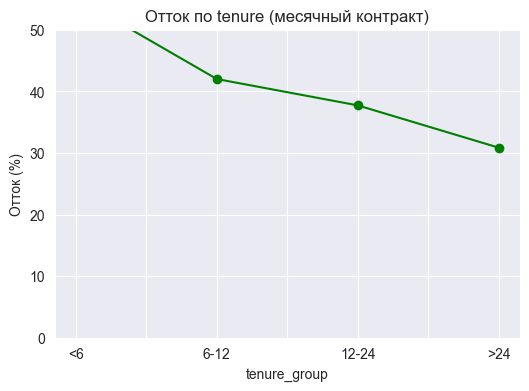

C:\Users\egor-\AppData\Local\Temp\ipykernel_12088\2546244871.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = subset.groupby('tenure_group')['Churn'].mean() * 100



=== Отток по tenure_group для контракта One year ===
tenure_group
<6       10.526316
6-12     10.588235
12-24     8.121827
>24      11.892361
Name: Churn, dtype: float64

=== Отток по tenure_group для контракта Two year ===
tenure_group
<6       0.000000
6-12     0.000000
12-24    0.000000
>24      3.122967
Name: Churn, dtype: float64

=== Отток по risk_score (чем выше score, тем лучше) ===
risk_score
0    62.461300
1    34.958999
2    10.171853
3     2.598425
Name: Churn, dtype: float64


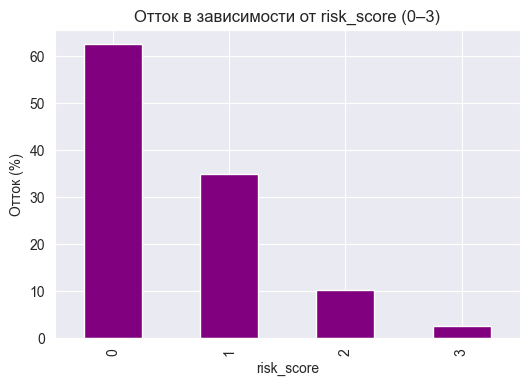


=== Качество простого правила (без ML) ===
Accuracy:  0.681
Precision: 0.448
Recall:    0.865
F1-score:  0.590
F1-score:  0.590


In [10]:
# -*- coding: utf-8 -*-
# Проект: Анализ оттока клиентов телеком-компании
# Автор: f1retruckthepudge-prog
# Дата: апрель 2026

# ==================== 1. Загрузка и первичная очистка ====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные (укажите свой путь к файлу)
df_raw = pd.read_csv(r"C:\Users\egor-\PycharmProjects\Churn project\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Преобразуем целевой признак
df_raw['Churn'] = (df_raw['Churn'] == 'Yes').astype(int)

# Преобразуем TotalCharges в число (коэрциция, ошибки -> NaN)
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')

# Удаляем строки с пропусками (очень мало)
df = df_raw.dropna().copy()

print(f"Загружено строк: {len(df)}")
print(f"Распределение Churn:\n{df['Churn'].value_counts()}")

# ==================== 2. Кейс 1: Тип контракта ====================

# Таблица оттока по типу контракта
churn_by_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print("\n=== Отток по типу контракта (%%) ===")
print(churn_by_contract)

# Визуализация
plt.figure(figsize=(6,4))
churn_by_contract[1].sort_values().plot(kind='bar', color='salmon')
plt.title('Отток по типу контракта')
plt.ylabel('Отток (%)')
plt.ylim(0, 50)
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 3. Кейс 2: Ежемесячные платежи (при фиксированном контракте) ====================

# Для каждого типа контракта посмотрим отток в зависимости от MonthlyCharges
contracts = df['Contract'].unique()
for contract in contracts:
    subset = df[df['Contract'] == contract].copy()
    # Разбиваем на 4 группы по квантилям MonthlyCharges
    subset['charge_group'] = pd.qcut(subset['MonthlyCharges'], q=4, labels=['Q1 (низкие)', 'Q2', 'Q3', 'Q4 (высокие)'])
    churn_by_charge = subset.groupby('charge_group')['Churn'].mean() * 100
    print(f"\n=== Отток по MonthlyCharges для контракта {contract} ===")
    print(churn_by_charge)

    # График для месячного контракта (самый интересный)
    if contract == 'Month-to-month':
        plt.figure(figsize=(6,4))
        churn_by_charge.plot(kind='bar', color='lightblue')
        plt.title(f'Отток по MonthlyCharges\n({contract})')
        plt.ylabel('Отток (%)')
        plt.savefig(f'churn_by_charge_{contract.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
        plt.show()

# ==================== 4. Кейс 3: Длительность обслуживания (tenure) с контролем контракта ====================

# Создаём группы tenure
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 100], labels=['<6', '6-12', '12-24', '>24'])

for contract in contracts:
    subset = df[df['Contract'] == contract].copy()
    churn_by_tenure = subset.groupby('tenure_group')['Churn'].mean() * 100
    print(f"\n=== Отток по tenure_group для контракта {contract} ===")
    print(churn_by_tenure)

    # График для месячного контракта
    if contract == 'Month-to-month':
        plt.figure(figsize=(6,4))
        churn_by_tenure.plot(kind='line', marker='o', color='green')
        plt.title(f'Отток по tenure (месячный контракт)')
        plt.ylabel('Отток (%)')
        plt.ylim(0, 50)
        plt.savefig('churn_by_tenure_monthly.png', dpi=150, bbox_inches='tight')
        plt.show()

# ==================== 5. Мини-модель (простое правило) ====================

# На основе инсайтов создаём правило:
# - Контракт не месячный → +1 (долгосрочный контракт снижает отток)
# - MonthlyCharges < 70 → +1 (низкая плата снижает отток)
# - tenure > 24 → +1 (лояльные клиенты)

def predict_churn_risk(row):
    score = 0
    if row['Contract'] != 'Month-to-month':
        score += 1
    if row['MonthlyCharges'] < 70:
        score += 1
    if row['tenure'] > 24:
        score += 1
    return score

df['risk_score'] = df.apply(predict_churn_risk, axis=1)

# Оценим правило: чем выше score, тем ниже отток?
risk_churn = df.groupby('risk_score')['Churn'].mean() * 100
print("\n=== Отток по risk_score (чем выше score, тем лучше) ===")
print(risk_churn)

# Визуализация
plt.figure(figsize=(6,4))
risk_churn.plot(kind='bar', color='purple')
plt.title('Отток в зависимости от risk_score (0–3)')
plt.ylabel('Отток (%)')
plt.savefig('risk_score_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 6. Итоговые метрики правила (accuracy) ====================

# Превращаем score в прогноз: score >= 2 → "не уйдёт" (0), иначе "уйдёт" (1)
df['pred_churn'] = (df['risk_score'] < 2).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(df['Churn'], df['pred_churn'])
prec = precision_score(df['Churn'], df['pred_churn'])
rec = recall_score(df['Churn'], df['pred_churn'])
f1 = f1_score(df['Churn'], df['pred_churn'])

print("\n=== Качество простого правила (без ML) ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
Accuracy:  0.681
Precision: 0.448
Recall:    0.865
print(f"F1-score:  {f1:.3f}")

In [18]:
df['Churn'].value_counts(normalize=True)





Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [20]:
df['Churn'].unique()


array([0, 1])

In [22]:
lost_users = df[df['Churn'] == 'Yes']


In [25]:
loss = lost_users['MonthlyCharges'].sum() * 12
print (loss)


0.0


In [28]:
# Доход
df['revenue_segment'] = pd.cut(df['MonthlyCharges'],
                              bins=[0,40,80,200],
                              labels=['Low','Mid','High'])



In [30]:
segment_table = df.groupby(
    ['Contract', 'revenue_segment', 'TechSupport']
).agg(
    users=('customerID','count'),
    churn_rate=('Churn', lambda x: (x=='Yes').mean()),
    avg_revenue=('MonthlyCharges','mean')
).reset_index()


C:\Users\egor-\AppData\Local\Temp\ipykernel_12088\2824836301.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_table = df.groupby(


In [32]:
segment_table['loss'] = (
    segment_table['users']
    * segment_table['churn_rate']
    * segment_table['avg_revenue']
    * 12
)


In [36]:
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')




In [41]:
segment_table = df.groupby(
    ['Contract', 'revenue_segment', 'TechSupport']
).agg(
    users=('customerID','count'),
    churn_rate=('Churn', lambda x: (x=='Yes').mean()),
    avg_revenue=('MonthlyCharges','mean')
).reset_index()



C:\Users\egor-\AppData\Local\Temp\ipykernel_12088\3173727393.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_table = df.groupby(


In [43]:
segment_table['loss'] = (
    segment_table['users']
    * segment_table['churn_rate']
    * segment_table['avg_revenue']
    * 12
)


In [45]:
segment_table.sort_values('loss', ascending=False)


,Contract,revenue_segment,TechSupport,users,churn_rate,avg_revenue,loss
0,Month-to-month,Low,No,195,0.0,30.050000,0.0
1,Month-to-month,Low,No internet service,524,0.0,20.409542,0.0
2,Month-to-month,Low,Yes,43,0.0,33.104651,0.0
3,Month-to-month,Mid,No,1342,0.0,62.983607,0.0
5,Month-to-month,Mid,Yes,306,0.0,61.111765,0.0
6,Month-to-month,High,No,1143,0.0,91.995188,0.0
8,Month-to-month,High,Yes,322,0.0,96.091925,0.0
9,One year,Low,No,27,0.0,32.924074,0.0
10,One year,Low,No internet service,363,0.0,20.822590,0.0
11,One year,Low,Yes,19,0.0,34.978947,0.0


In [47]:
df['Churn'].unique()


array([0, 1])

In [54]:
churn_rate = df['Churn'].mean()



In [63]:
df['Churn'].unique()
df['Churn'].dtype



dtype('int64')

In [65]:
churn_rate=('Churn','mean')


In [67]:
segment_table = df.groupby(
    ['Contract', 'revenue_segment', 'TechSupport']
).agg(
    users=('customerID','count'),
    churn_rate=('Churn','mean'),
    avg_revenue=('MonthlyCharges','mean')
).reset_index()


C:\Users\egor-\AppData\Local\Temp\ipykernel_12088\1241020633.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_table = df.groupby(


In [2]:
import os
os.makedirs('images', exist_ok=True)


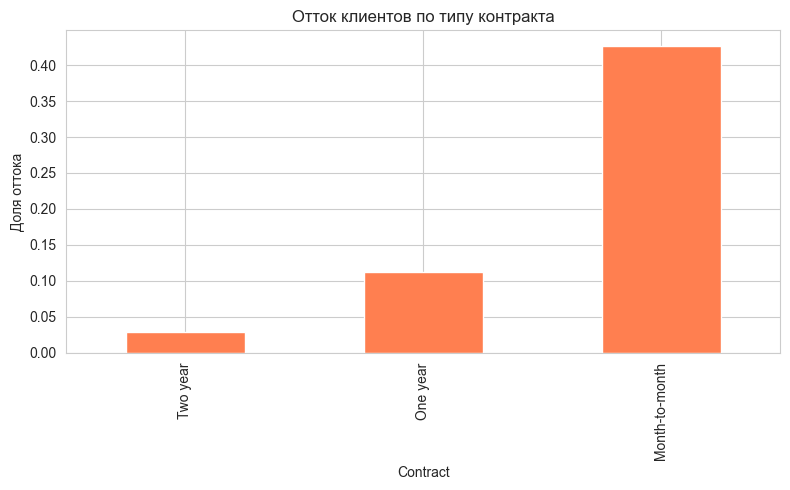

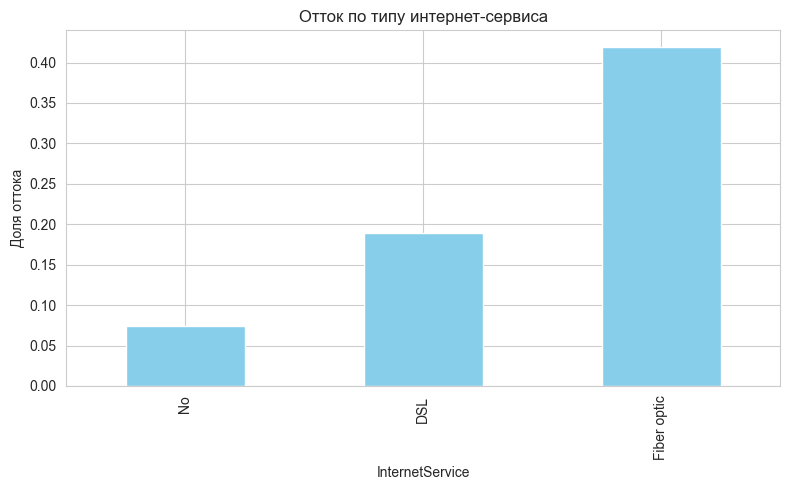

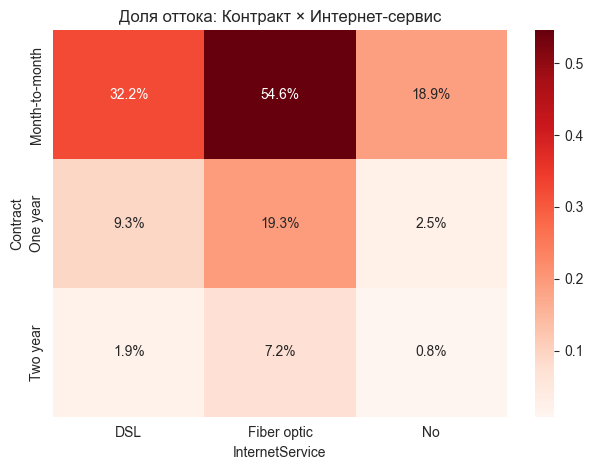

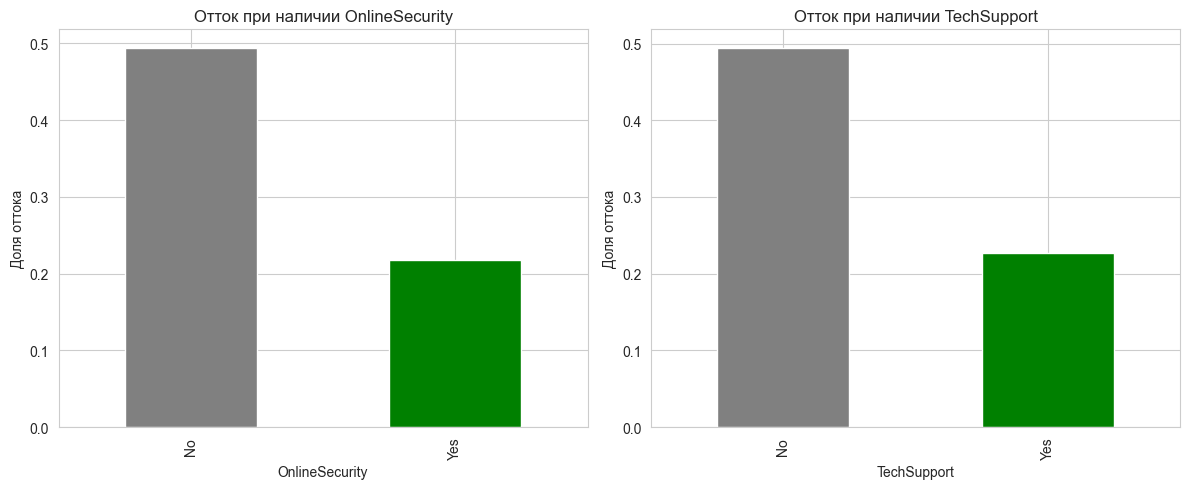

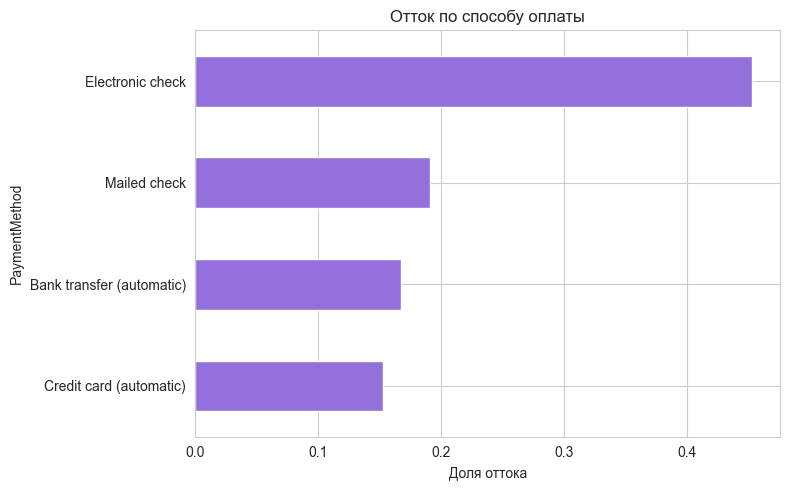

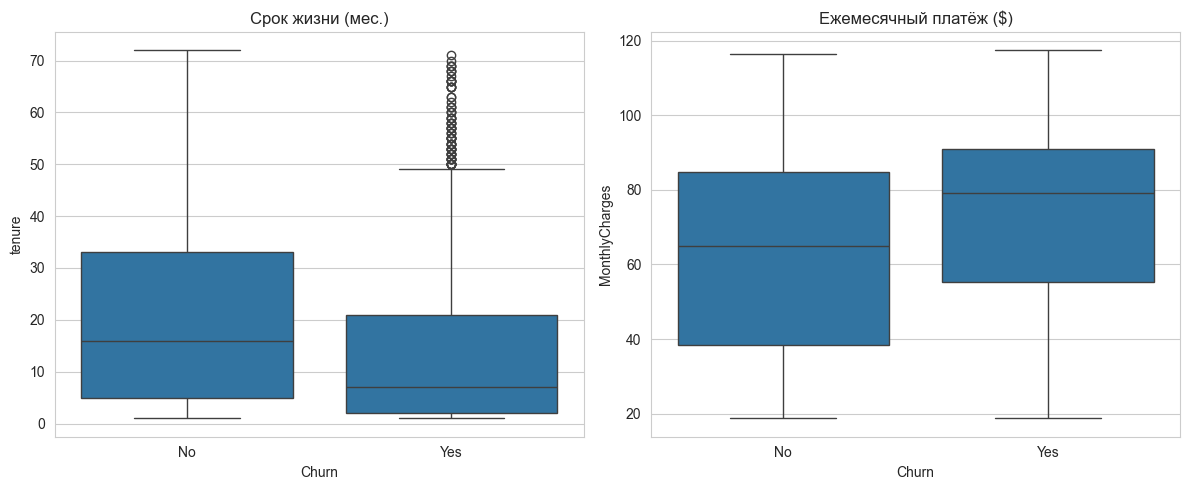

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Загрузка данных
df = pd.read_csv('C:/temp/telco.csv.csv')  # или 'data/telco.csv', если перенесёшь

# График 1: Отток по типу контракта
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()['Yes'].sort_values()
contract_churn.plot(kind='bar', color='coral', figsize=(8,5))
plt.title('Отток клиентов по типу контракта')
plt.ylabel('Доля оттока')
plt.tight_layout()
plt.savefig('images/contract_churn.png', dpi=150)
plt.show()

# График 2: Интернет-сервис и отток
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()['Yes'].sort_values()
internet_churn.plot(kind='bar', color='skyblue', figsize=(8,5))
plt.title('Отток по типу интернет-сервиса')
plt.ylabel('Доля оттока')
plt.tight_layout()
plt.savefig('images/internet_churn.png', dpi=150)
plt.show()

# График 3: Тепловая карта контракт vs интернет
pivot = df.pivot_table(index='Contract', columns='InternetService', values='Churn',
                       aggfunc=lambda x: (x == 'Yes').mean())
sns.heatmap(pivot, annot=True, cmap='Reds', fmt='.1%')
plt.title('Доля оттока: Контракт × Интернет-сервис')
plt.tight_layout()
plt.savefig('images/contract_internet_heatmap.png', dpi=150)
plt.show()

# График 4: Влияние OnlineSecurity и TechSupport (Fiber optic)
fiber = df[df['InternetService'] == 'Fiber optic']
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, col in zip(axes, ['OnlineSecurity', 'TechSupport']):
    data = fiber.groupby(col)['Churn'].value_counts(normalize=True).unstack()['Yes']
    data.plot(kind='bar', ax=ax, color=['grey','green'])
    ax.set_title(f'Отток при наличии {col}')
    ax.set_ylabel('Доля оттока')
plt.tight_layout()
plt.savefig('images/services_churn.png', dpi=150)
plt.show()

# График 5: Способ оплаты и отток
pay = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack()['Yes'].sort_values()
pay.plot(kind='barh', color='mediumpurple', figsize=(8,5))
plt.title('Отток по способу оплаты')
plt.xlabel('Доля оттока')
plt.tight_layout()
plt.savefig('images/payment_churn.png', dpi=150)
plt.show()

# График 6: Срок жизни и чек у ушедших/оставшихся (помесячные)
monthly = df[df['Contract'] == 'Month-to-month']
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x='Churn', y='tenure', data=monthly, ax=axes[0])
axes[0].set_title('Срок жизни (мес.)')
sns.boxplot(x='Churn', y='MonthlyCharges', data=monthly, ax=axes[1])
axes[1].set_title('Ежемесячный платёж ($)')
plt.tight_layout()
plt.savefig('images/tenure_charges_boxplot.png', dpi=150)
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

# Подготовка данных: удаляем ненужные ID, преобразуем TotalCharges в float
df_model = df.copy()
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model.dropna(subset=['TotalCharges'], inplace=True)

# Кодируем категориальные признаки
cat_cols = df_model.select_dtypes(include='object').columns.difference(['customerID', 'Churn'])
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Целевая переменная
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# Признаки (упрощённо, без customerID)
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService',
            'OnlineSecurity', 'TechSupport', 'PaymentMethod']
X = df_model[features]
y = df_model['Churn']

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Модель
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Оценка
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1549
           1       0.59      0.53      0.56       561

    accuracy                           0.78      2110
   macro avg       0.72      0.70      0.71      2110
weighted avg       0.77      0.78      0.78      2110

ROC-AUC: 0.8266100031185665


In [7]:
import plotly.express as px
df = pd.read_csv('C:/temp/telco.csv.csv')
fig = px.histogram(df, x='Contract', color='Churn', barmode='group',
                   title='Отток по типу контракта (интерактивный)')
fig.show()

In [9]:
fig.write_html('images/contract_churn_interactive.html')

In [13]:
pivot = df.pivot_table(index='Contract', columns='InternetService', values='Churn',
                       aggfunc=lambda x: (x == 'Yes').mean())
fig = px.imshow(pivot, text_auto='.1%', color_continuous_scale='Reds',
                title='Доля оттока: Контракт × Интернет-сервис')
fig.write_html('images/contract_internet_heatmap_interactive.html')

In [15]:
fig = px.scatter(df, x='tenure', y='MonthlyCharges', color='Churn',
                 opacity=0.6, title='Срок жизни и ежемесячный платёж')
fig.write_html('images/tenure_charges_scatter.html')

In [16]:
import ipywidgets as widgets
from IPython.display import display

contract_dropdown = widgets.Dropdown(options=['All'] + list(df['Contract'].unique()),
                                     value='All', description='Контракт:')
def update(contract):
    filtered = df if contract == 'All' else df[df['Contract'] == contract]
    fig = px.histogram(filtered, x='InternetService', color='Churn', barmode='group',
                       title=f'Отток по интернет-сервисам (контракт: {contract})')
    fig.show()
widgets.interact(update, contract=contract_dropdown)

interactive(children=(Dropdown(description='Контракт:', options=('All', 'Month-to-month', 'One year', 'Two yea…

<function __main__.update(contract)>